### 1) Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os,cv2
from sklearn.model_selection import train_test_split 
from sklearn.utils import shuffle
import tensorflow as tf
# from keras.applications import ResNet50
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.utils.class_weight import compute_class_weight


### 2) Classes Labeling

In [9]:
Class_names=['NORMAL','PNEUMONIA']
Class_names_encoder={class_name:i for i,class_name in enumerate(Class_names)}
classes_num=len(Class_names_encoder)
classes_num,Class_names_encoder


(2, {'NORMAL': 0, 'PNEUMONIA': 1})

### 3) Important PreDefine 

In [12]:
IMAGE_SIZE=(224,224)

### 4)Data Reading

In [15]:
datasets=[r'archive (1)/chest_xray/train',
         r'archive (1)/chest_xray/test',
         r'archive (1)/chest_xray/val']
output=[]
for dataset in datasets:
    images=[]
    labels=[]
    for folder in os.listdir(dataset):
        label=Class_names_encoder[folder]
        folderpath=os.path.join(dataset,folder)
        imagesoffolder=os.listdir(folderpath)
        for i in range(len(imagesoffolder)):
            imagepath=os.path.join(folderpath,imagesoffolder[i])
            image=cv2.imread(imagepath)
            image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
            image=cv2.resize(image,IMAGE_SIZE)
            images.append(image)
            labels.append(label)
    images=np.array(images)
    labels=np.array(labels)
    output.append((images,labels))

### 5)Checks

In [18]:
len(output[0][1]),len(output[0][0])

(5216, 5216)

In [20]:
len(output[1][1]),len(output[1][0])

(624, 624)

In [22]:
len(output[2][1]),len(output[2][0])

(16, 16)

In [24]:
output[0][0].shape,output[1][0].shape,output[2][0].shape

((5216, 224, 224, 3), (624, 224, 224, 3), (16, 224, 224, 3))

### 6) Data Spliting

In [27]:
Train_images=output[0][0]
Train_labels=output[0][1]
Test_images=output[1][0]
Test_labels=output[1][1]
Val_images=output[2][0]
Val_label=output[2][1]

In [29]:
####
X = np.concatenate([Train_images,Test_images, Val_images], axis=0)
y = np.concatenate([Train_labels,Test_labels, Val_label], axis=0)


In [ ]:
####
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
    shuffle=True
)

In [33]:
X_train.shape,y_train.shape

((4392, 224, 224, 3), (4392,))

In [35]:
####
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42,
    shuffle=True
)

### 7)Visualization

In [38]:
pd.Series(y_train).value_counts()

1    2884
0    1068
Name: count, dtype: int64

In [40]:
invClass_names_encoder={i:class_name for i,class_name in enumerate(Class_names)}


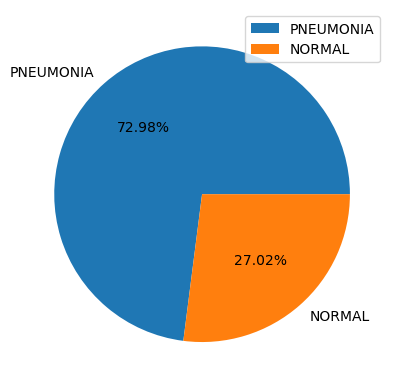

In [42]:
plt.pie(pd.Series(y_train).value_counts(),labels=[invClass_names_encoder[i] for i in pd.Series(y_train).value_counts().index],autopct='%0.2f%%')
plt.legend()
plt.show()

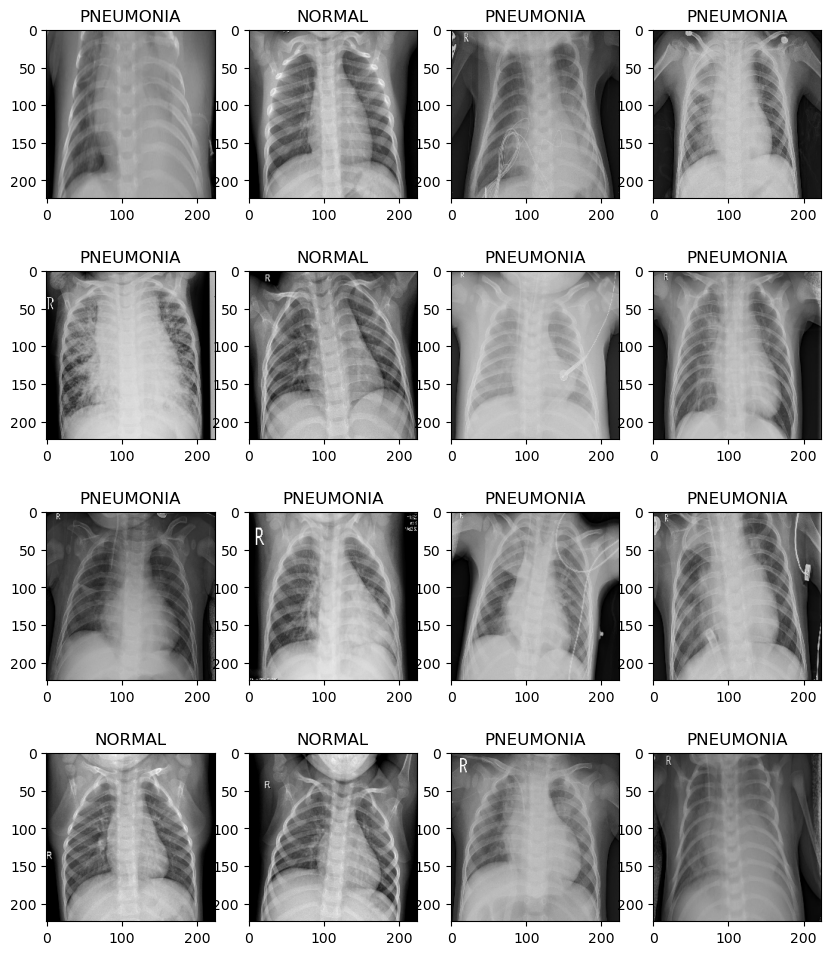

In [44]:
plt.figure(figsize=(10,12))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.title(invClass_names_encoder[y_train[i]])
    plt.imshow(X_train[i])
plt.show()

In [45]:
X_train = preprocess_input(X_train.astype("float32"))
X_val   = preprocess_input(X_val.astype("float32"))
X_test = preprocess_input(X_test.astype("float32"))

In [47]:
datagen = ImageDataGenerator(
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)


In [50]:
Train_generator = datagen.flow(X_train, y_train, batch_size=64)

In [52]:
model=tf.keras.models.Sequential()
model.add(MobileNetV2(weights='imagenet',input_shape=(224,224,3),pooling='avg',include_top=False))
tf.keras.layers.Dropout(0.5),
tf.keras.layers.Dense(128, activation='relu'),
tf.keras.layers.Dropout(0.3),
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

In [121]:
# model=tf.keras.models.Sequential()
# model.add(ResNet50(weights='imagenet',input_shape=(224,224,3),pooling='avg',include_top=False))
# tf.keras.layers.Dropout(0.5),
# tf.keras.layers.Dense(128, activation='relu'),
# tf.keras.layers.Dropout(0.3),
# model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

In [54]:
model.layers[0].trainable=False

In [56]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [58]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,           
    patience=3,           
    min_lr=1e-6           
)

In [60]:
early_stoping=tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=5,
                                                    restore_best_weights=True)

In [54]:
history=model.fit(Train_generator,epochs=10,verbose=1,validation_data = (X_val, y_val),
                     callbacks= [early_stoping,lr_scheduler])

C:\Users\sh\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - accuracy: 0.7068 - loss: 0.6613 - val_accuracy: 0.8168 - val_loss: 0.4329 - learning_rate: 1.0000e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.8452 - loss: 0.3719 - val_accuracy: 0.9065 - val_loss: 0.2965 - learning_rate: 1.0000e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.9046 - loss: 0.2767 - val_accuracy: 0.9198 - val_loss: 0.2371 - learning_rate: 1.0000e-04
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 290s 4s/step - accuracy: 0.9212 - loss: 0.2221 - val_accuracy: 0.9275 - val_loss: 0.2066 - learning_rate: 1.0000e-04
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 294s 4s/step - accuracy: 0.9320 - loss: 0.2011 - val_accuracy: 0.9313 - val_loss: 0.1861 - learning_rate: 1.0000e-04
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 293s 4s/step - accuracy: 0.9308 - loss: 0.1847 - val_accuracy: 0.9351 - val_loss: 0.1708 - learning_rate: 1.0000e-04
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 291s 4s/step - accuracy: 0.9340 

In [56]:
model.evaluate(Test_images,Test_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.6530 - loss: 0.6660


[0.40928131341934204, 0.7980769276618958]

In [58]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 2048)                │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,593,861 (90.00 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 4,100 (16.02 KB)

In [60]:
predict_image=model.predict(Test_images)

20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step


In [62]:
predict_image=[round(i[0]) for i in predict_image]
predict_image

[0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [64]:
Test_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

C:\Users\sh\AppData\Local\Temp\ipykernel_14768\868731250.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


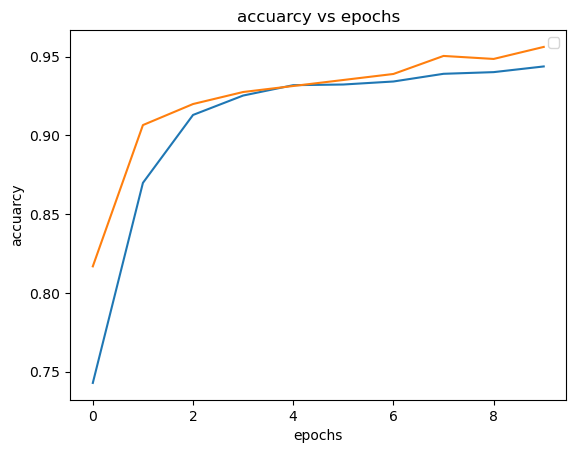

In [66]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuarcy')
plt.title('accuarcy vs epochs')
plt.legend()
plt.show()

C:\Users\sh\AppData\Local\Temp\ipykernel_14768\518395082.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


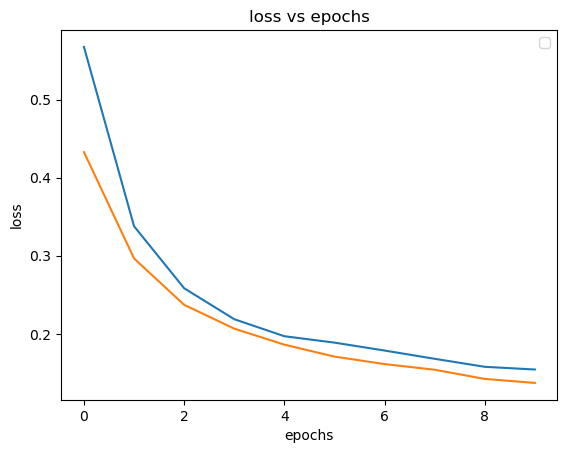

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss vs epochs')
plt.legend()
plt.show()

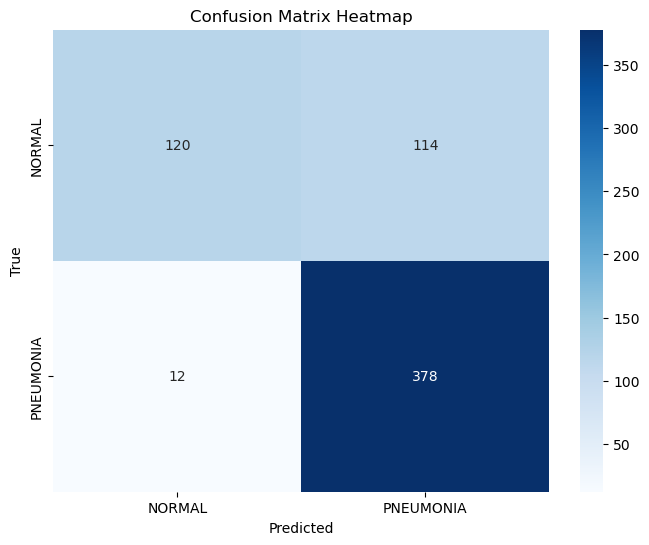

In [70]:
cm=confusion_matrix(Test_labels,predict_image)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=Class_names, yticklabels=Class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [72]:
print(classification_report(Test_labels,predict_image))

              precision    recall  f1-score   support

           0       0.91      0.51      0.66       234
           1       0.77      0.97      0.86       390

    accuracy                           0.80       624
   macro avg       0.84      0.74      0.76       624
weighted avg       0.82      0.80      0.78       624



In [62]:
base_model = model.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [64]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [66]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(np.unique(y_train), weights))

print(class_weights)

{0: 1.850187265917603, 1: 0.6851595006934813}


In [68]:
history = model.fit(
    Train_generator,
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=[early_stoping, lr_scheduler],
    class_weight=class_weights
)

C:\Users\sh\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8673 - loss: 0.3044 - val_accuracy: 0.8795 - val_loss: 0.2477 - learning_rate: 1.0000e-04
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9611 - loss: 0.1065 - val_accuracy: 0.8636 - val_loss: 0.2910 - learning_rate: 1.0000e-04
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.9705 - loss: 0.0817 - val_accuracy: 0.8977 - val_loss: 0.2413 - learning_rate: 1.0000e-04
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9734 - loss: 0.0643 - val_accuracy: 0.9659 - val_loss: 0.1152 - learning_rate: 1.0000e-04
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9767 - loss: 0.0565 - val_accuracy: 0.9705 - val_loss: 0.1078 - learning_rate: 1.0000e-04
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9832 - loss: 0.0411 - val_accuracy: 0.9591 - val_loss: 0.0943 - learning_rate: 1.0000e-04
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9838 

In [70]:
model.evaluate(X_test,y_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 380ms/step - accuracy: 0.9627 - loss: 0.1225


[0.11536993086338043, 0.9644808769226074]

In [72]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,313,989 (20.27 MB)

 Trainable params: 1,527,361 (5.83 MB)

 Non-trainable params: 731,904 (2.79 MB)

 Optimizer params: 3,054,724 (11.65 MB)

In [74]:
predict_image=model.predict(X_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 437ms/step


In [76]:
predict_image=[round(i[0]) for i in predict_image]
predict_image

[0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,


In [78]:
print(y_test),len(y_test)

[0 0 1 ... 0 1 0]


(None, 1464)

In [80]:
(y_test == predict_image).sum()

1412

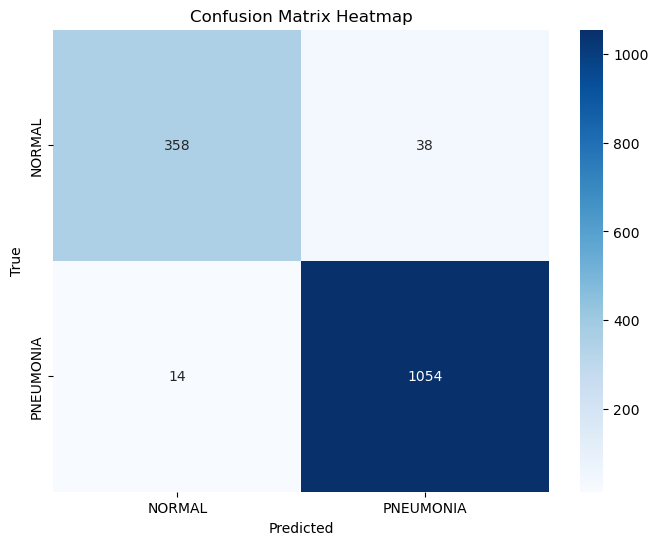

In [82]:
cm=confusion_matrix(y_test,predict_image)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=Class_names, yticklabels=Class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [84]:
print(classification_report(y_test,predict_image))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       396
           1       0.97      0.99      0.98      1068

    accuracy                           0.96      1464
   macro avg       0.96      0.95      0.95      1464
weighted avg       0.96      0.96      0.96      1464



C:\Users\sh\AppData\Local\Temp\ipykernel_1972\868731250.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


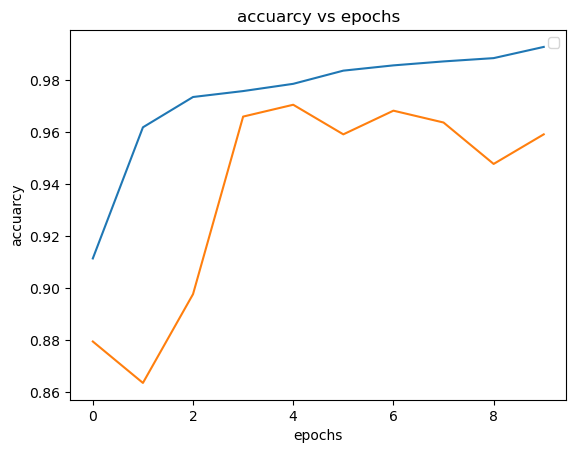

In [86]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuarcy')
plt.title('accuarcy vs epochs')
plt.legend()
plt.show()

C:\Users\sh\AppData\Local\Temp\ipykernel_1972\518395082.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


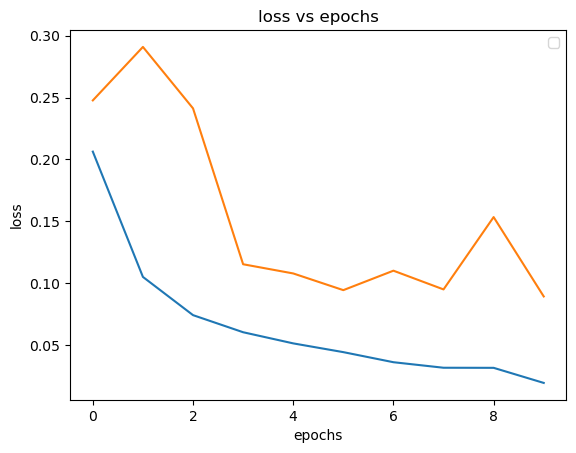

In [88]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss vs epochs')
plt.legend()
plt.show()

In [90]:
model.save("X_RAY_MOBILENET.keras")